# Step 3 — Fine-tuning promptu: default vs filmweb vs typed

8 modeli · 3 warianty promptu (`default_pl`, `filmweb_pl`, `typed_pl`) · 3 artykuły  
Pytanie: czy zmiana promptu poprawia wyniki i który prompt wygrywa?

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, HTML

def short_label(m):
    if m.startswith("local:"):
        m = m[len("local:"):]
    if "/" in m:
        m = m.rsplit("/", 1)[-1]
    return m

def parse_rate(s):
    try:
        a, b = s.split("|")
        return int(a.strip()) / int(b.strip())
    except:
        return float("nan")

def f1(p, r):
    return 2 * p * r / (p + r) if (p + r) > 0 else 0

df = pd.read_csv("step_3_fine_tuning_prompt.csv")
df.columns = [c.strip().lower().replace("-", "_") for c in df.columns]
df["model_short"] = df["model"].apply(short_label)
df["title_short"] = df["title"].str.replace("_", " ")
df["prompt_label"] = df["prompt"].str.split("/").str[0].str.replace("_pl", "")
df["hall_rate"] = df["hall"].apply(parse_rate)
df["miss_rate"] = df["miss"].apply(parse_rate)
df["f1"]   = df.apply(lambda r: f1(r["precision"], r["recall"]), axis=1).round(3)
df["t_f1"] = df.apply(lambda r: f1(r["t_precision"], r["t_recall"]), axis=1).round(3)

NUMERIC = ["precision", "recall", "f1", "t_precision", "t_recall", "t_f1"]
PROMPTS = ["default", "filmweb", "typed"]
PROMPT_COLORS = {"default": "#4878d0", "filmweb": "#ee854a", "typed": "#6acc65"}

print(f"{len(df)} wierszy | {df['model_short'].nunique()} modeli | {df['prompt_label'].nunique()} prompty | {df['title_short'].nunique()} artykuły")
df[["model_short", "prompt_label", "title_short"]].value_counts().sort_index()

72 wierszy | 8 modeli | 3 prompty | 3 artykuły


model_short               prompt_label  title_short                                          
bielik-11b-v3.0-instruct  default       Langer serial SkyShowtime                                1
                                        The Last of Us odcinek 5 tworcy o szokujacych scenach    1
                                        Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy        1
                          filmweb       Langer serial SkyShowtime                                1
                                        The Last of Us odcinek 5 tworcy o szokujacych scenach    1
                                                                                                ..
qwen3-vl-8b               filmweb       The Last of Us odcinek 5 tworcy o szokujacych scenach    1
                                        Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy        1
                          typed         Langer serial SkyShowtime                                1
               

## Pełna tabela wyników (per artykuł)

In [20]:
DISPLAY_COLS = ["model_short", "prompt_label", "precision", "recall", "f1",
                "hall", "miss", "t_precision", "t_recall", "t_f1", "t_hall", "t_miss"]
RENAME = {"model_short": "Model", "prompt_label": "Prompt",
          "precision": "Prec.", "recall": "Recall", "f1": "F1",
          "hall": "Hall.", "miss": "Miss.",
          "t_precision": "T-Prec.", "t_recall": "T-Recall", "t_f1": "T-F1",
          "t_hall": "T-Hall.", "t_miss": "T-Miss."}
GRAD = ["Prec.", "Recall", "F1", "T-Prec.", "T-Recall", "T-F1"]
FMT  = {c: "{:.1%}" for c in GRAD}

PROMPT_ROW_COLORS = {"default": "#eef3fb", "filmweb": "#fff8f2", "typed": "#f0fff0"}

def color_prompt(row):
    key = row.get("Prompt", row.get("prompt_label", ""))
    color = PROMPT_ROW_COLORS.get(key, "")
    return [f"background-color: {color}" for _ in row]

for sort_col, sort_label in [("precision", "Precision"), ("t_precision", "T-Precision")]:
    display(HTML(f"<h3>Sortowanie wg {sort_label}</h3>"))
    for article, group in df.groupby("title_short"):
        display(HTML(f"<h4>{article}</h4>"))
        display(
            group[DISPLAY_COLS]
            .sort_values(sort_col, ascending=False)
            .rename(columns=RENAME)
            .style
            .apply(color_prompt, axis=1)
            .background_gradient(subset=GRAD, cmap="RdYlGn", vmin=0, vmax=1)
            .format(FMT)
            .set_table_styles([{"selector": "th", "props": [("white-space", "nowrap")]}])
            .hide(axis="index")
        )

Model,Prompt,Prec.,Recall,F1,Hall.,Miss.,T-Prec.,T-Recall,T-F1,T-Hall.,T-Miss.
gemma-4-26b-a4b-it,filmweb,100.0%,78.4%,87.9%,0 | 29,8 | 37,100.0%,82.9%,90.7%,0 | 29,6 | 35
gemma-4-31b-it,filmweb,100.0%,81.0%,89.5%,0 | 17,4 | 21,100.0%,48.6%,65.4%,0 | 17,18 | 35
bielik-11b-v3.0-instruct,default,100.0%,46.2%,63.2%,0 | 12,14 | 26,100.0%,18.2%,30.8%,0 | 12,54 | 66
bielik-11b-v3.0-instruct,filmweb,100.0%,66.7%,80.0%,0 | 14,7 | 21,92.9%,37.1%,53.0%,1 | 14,22 | 35
mistral-small-3.2-24b-instruct,filmweb,100.0%,59.0%,74.2%,0 | 23,16 | 39,78.3%,51.4%,62.1%,5 | 23,17 | 35
qwen3-32b,filmweb,100.0%,81.8%,90.0%,0 | 18,4 | 22,94.4%,48.6%,64.2%,1 | 18,18 | 35
mistral-small-3.2-24b-instruct,default,97.9%,64.8%,78.0%,1 | 47,25 | 71,93.6%,66.7%,77.9%,3 | 47,22 | 66
qwen3-vl-8b,default,96.8%,62.5%,76.0%,1 | 31,18 | 48,77.4%,36.4%,49.5%,7 | 31,42 | 66
qwen3-30b-a3b-instruct-2507,typed,96.7%,72.5%,82.9%,1 | 30,11 | 40,40.0%,63.2%,49.0%,18 | 30,7 | 19
gemma-4-26b-a4b-it,default,95.8%,56.1%,70.8%,1 | 24,18 | 41,95.8%,34.8%,51.1%,1 | 24,43 | 66


Model,Prompt,Prec.,Recall,F1,Hall.,Miss.,T-Prec.,T-Recall,T-F1,T-Hall.,T-Miss.
gemma-4-31b-it,typed,100.0%,66.7%,80.0%,0 | 12,6 | 18,66.7%,53.3%,59.3%,4 | 12,7 | 15
bielik-11b-v3.0-instruct,typed,100.0%,41.2%,58.4%,0 | 7,10 | 17,42.9%,20.0%,27.3%,4 | 7,12 | 15
gemma-4-31b-it,default,100.0%,71.0%,83.0%,0 | 22,9 | 31,90.9%,55.6%,69.0%,2 | 22,16 | 36
qwen3-14b,typed,96.0%,80.0%,87.3%,1 | 25,6 | 30,32.0%,53.3%,40.0%,17 | 25,7 | 15
qwen3-14b,default,95.7%,66.7%,78.6%,1 | 23,11 | 33,82.6%,52.8%,64.4%,4 | 23,17 | 36
gemma-4-26b-a4b-it,typed,94.4%,63.0%,75.6%,1 | 18,10 | 27,38.9%,46.7%,42.4%,11 | 18,8 | 15
qwen3-30b-a3b-instruct-2507,default,92.1%,79.5%,85.3%,3 | 38,9 | 44,55.3%,58.3%,56.8%,17 | 38,15 | 36
qwen3-32b,filmweb,90.9%,66.7%,76.9%,1 | 11,5 | 15,81.8%,75.0%,78.3%,2 | 11,3 | 12
qwen3-vl-8b,typed,89.7%,76.5%,82.6%,3 | 29,8 | 34,41.4%,80.0%,54.6%,17 | 29,3 | 15
bielik-11b-v3.0-instruct,filmweb,88.9%,66.7%,76.2%,1 | 9,4 | 12,100.0%,75.0%,85.7%,0 | 9,3 | 12


Model,Prompt,Prec.,Recall,F1,Hall.,Miss.,T-Prec.,T-Recall,T-F1,T-Hall.,T-Miss.
gemma-4-31b-it,filmweb,100.0%,69.0%,81.7%,0 | 29,13 | 42,100.0%,65.9%,79.4%,0 | 29,15 | 44
bielik-11b-v3.0-instruct,typed,100.0%,32.0%,48.5%,0 | 8,17 | 25,100.0%,19.0%,31.9%,0 | 8,34 | 42
bielik-11b-v3.0-instruct,filmweb,100.0%,26.9%,42.4%,0 | 7,19 | 26,71.4%,11.4%,19.7%,2 | 7,39 | 44
gemma-4-31b-it,default,100.0%,76.7%,86.8%,0 | 46,14 | 60,91.3%,60.0%,72.4%,4 | 46,28 | 70
mistral-small-3.2-24b-instruct,default,100.0%,78.8%,88.1%,0 | 52,14 | 66,86.5%,64.3%,73.8%,7 | 52,25 | 70
bielik-11b-v3.0-instruct,default,100.0%,44.9%,62.0%,0 | 22,27 | 49,86.4%,27.1%,41.3%,3 | 22,51 | 70
gemma-4-26b-a4b-it,filmweb,97.6%,80.0%,87.9%,1 | 41,10 | 50,95.1%,88.6%,91.7%,2 | 41,5 | 44
qwen3-14b,typed,97.6%,69.0%,80.8%,1 | 41,18 | 58,58.5%,57.1%,57.8%,17 | 41,18 | 42
qwen3-30b-a3b-instruct-2507,filmweb,97.0%,65.3%,78.1%,1 | 33,17 | 49,81.8%,61.4%,70.1%,6 | 33,17 | 44
qwen3-14b,filmweb,95.7%,48.9%,64.7%,1 | 23,23 | 45,78.3%,40.9%,53.7%,5 | 23,26 | 44


Model,Prompt,Prec.,Recall,F1,Hall.,Miss.,T-Prec.,T-Recall,T-F1,T-Hall.,T-Miss.
gemma-4-26b-a4b-it,filmweb,100.0%,78.4%,87.9%,0 | 29,8 | 37,100.0%,82.9%,90.7%,0 | 29,6 | 35
bielik-11b-v3.0-instruct,default,100.0%,46.2%,63.2%,0 | 12,14 | 26,100.0%,18.2%,30.8%,0 | 12,54 | 66
gemma-4-31b-it,default,90.9%,62.5%,74.1%,2 | 22,12 | 32,100.0%,33.3%,50.0%,0 | 22,44 | 66
gemma-4-31b-it,filmweb,100.0%,81.0%,89.5%,0 | 17,4 | 21,100.0%,48.6%,65.4%,0 | 17,18 | 35
qwen3-30b-a3b-instruct-2507,default,80.0%,48.8%,60.6%,5 | 25,21 | 41,96.0%,36.4%,52.8%,1 | 25,42 | 66
gemma-4-26b-a4b-it,default,95.8%,56.1%,70.8%,1 | 24,18 | 41,95.8%,34.8%,51.1%,1 | 24,43 | 66
gemma-4-31b-it,typed,90.0%,66.7%,76.6%,2 | 20,9 | 27,95.0%,100.0%,97.4%,1 | 20,0 | 19
qwen3-32b,filmweb,100.0%,81.8%,90.0%,0 | 18,4 | 22,94.4%,48.6%,64.2%,1 | 18,18 | 35
mistral-small-3.2-24b-instruct,default,97.9%,64.8%,78.0%,1 | 47,25 | 71,93.6%,66.7%,77.9%,3 | 47,22 | 66
bielik-11b-v3.0-instruct,filmweb,100.0%,66.7%,80.0%,0 | 14,7 | 21,92.9%,37.1%,53.0%,1 | 14,22 | 35


Model,Prompt,Prec.,Recall,F1,Hall.,Miss.,T-Prec.,T-Recall,T-F1,T-Hall.,T-Miss.
bielik-11b-v3.0-instruct,filmweb,88.9%,66.7%,76.2%,1 | 9,4 | 12,100.0%,75.0%,85.7%,0 | 9,3 | 12
mistral-small-3.2-24b-instruct,filmweb,84.6%,68.8%,75.9%,2 | 13,5 | 16,92.3%,100.0%,96.0%,1 | 13,0 | 12
gemma-4-31b-it,default,100.0%,71.0%,83.0%,0 | 22,9 | 31,90.9%,55.6%,69.0%,2 | 22,16 | 36
gemma-4-26b-a4b-it,filmweb,70.0%,53.8%,60.8%,3 | 10,6 | 13,90.0%,75.0%,81.8%,1 | 10,3 | 12
qwen3-30b-a3b-instruct-2507,filmweb,70.0%,58.3%,63.6%,3 | 10,5 | 12,90.0%,75.0%,81.8%,1 | 10,3 | 12
gemma-4-31b-it,filmweb,77.8%,53.8%,63.6%,2 | 9,6 | 13,88.9%,66.7%,76.2%,1 | 9,4 | 12
gemma-4-26b-a4b-it,default,86.4%,63.3%,73.1%,3 | 22,11 | 30,86.4%,52.8%,65.5%,3 | 22,17 | 36
qwen3-14b,default,95.7%,66.7%,78.6%,1 | 23,11 | 33,82.6%,52.8%,64.4%,4 | 23,17 | 36
qwen3-vl-8b,default,81.8%,56.2%,66.6%,4 | 22,14 | 32,81.8%,50.0%,62.1%,4 | 22,18 | 36
qwen3-32b,filmweb,90.9%,66.7%,76.9%,1 | 11,5 | 15,81.8%,75.0%,78.3%,2 | 11,3 | 12


Model,Prompt,Prec.,Recall,F1,Hall.,Miss.,T-Prec.,T-Recall,T-F1,T-Hall.,T-Miss.
gemma-4-31b-it,filmweb,100.0%,69.0%,81.7%,0 | 29,13 | 42,100.0%,65.9%,79.4%,0 | 29,15 | 44
bielik-11b-v3.0-instruct,typed,100.0%,32.0%,48.5%,0 | 8,17 | 25,100.0%,19.0%,31.9%,0 | 8,34 | 42
qwen3-14b,default,90.2%,67.3%,77.1%,4 | 41,18 | 55,97.6%,57.1%,72.0%,1 | 41,30 | 70
gemma-4-26b-a4b-it,filmweb,97.6%,80.0%,87.9%,1 | 41,10 | 50,95.1%,88.6%,91.7%,2 | 41,5 | 44
gemma-4-31b-it,default,100.0%,76.7%,86.8%,0 | 46,14 | 60,91.3%,60.0%,72.4%,4 | 46,28 | 70
gemma-4-26b-a4b-it,default,90.7%,79.0%,84.4%,5 | 54,13 | 62,87.0%,67.1%,75.8%,7 | 54,23 | 70
mistral-small-3.2-24b-instruct,default,100.0%,78.8%,88.1%,0 | 52,14 | 66,86.5%,64.3%,73.8%,7 | 52,25 | 70
bielik-11b-v3.0-instruct,default,100.0%,44.9%,62.0%,0 | 22,27 | 49,86.4%,27.1%,41.3%,3 | 22,51 | 70
qwen3-30b-a3b-instruct-2507,default,93.9%,53.4%,68.1%,2 | 33,27 | 58,84.8%,40.0%,54.4%,5 | 33,42 | 70
mistral-small-3.2-24b-instruct,filmweb,90.2%,80.4%,85.0%,4 | 41,9 | 46,82.9%,77.3%,80.0%,7 | 41,10 | 44


## Średnie per model × prompt (wszystkie artykuły)

In [21]:
avg_mp = (
    df.groupby(["model_short", "prompt_label"])[NUMERIC]
    .mean().round(3).reset_index()
)

for sort_col, sort_label in [("precision", "Precision"), ("t_precision", "T-Precision")]:
    display(HTML(f"<h4>Ranking wg {sort_label}</h4>"))
    display(
        avg_mp.sort_values(sort_col, ascending=False)
        .rename(columns={"model_short": "Model", "prompt_label": "Prompt",
                         "precision": "Prec.", "recall": "Recall", "f1": "F1",
                         "t_precision": "T-Prec.", "t_recall": "T-Recall", "t_f1": "T-F1"})
        .style
        .apply(color_prompt, axis=1)
        .background_gradient(subset=["Prec.","Recall","F1","T-Prec.","T-Recall","T-F1"], cmap="RdYlGn", vmin=0, vmax=1)
        .format({c: "{:.1%}" for c in ["Prec.","Recall","F1","T-Prec.","T-Recall","T-F1"]})
        .set_table_styles([{"selector": "th", "props": [("white-space", "nowrap")]}])
        .hide(axis="index")
    )

Model,Prompt,Prec.,Recall,F1,T-Prec.,T-Recall,T-F1
gemma-4-31b-it,default,97.0%,70.1%,81.3%,94.1%,49.6%,63.8%
bielik-11b-v3.0-instruct,filmweb,96.3%,53.4%,66.2%,88.1%,41.2%,52.8%
bielik-11b-v3.0-instruct,default,94.9%,47.8%,63.3%,85.2%,23.4%,36.3%
bielik-11b-v3.0-instruct,typed,94.7%,49.4%,62.0%,73.0%,46.3%,48.5%
gemma-4-26b-a4b-it,typed,94.0%,66.9%,77.7%,65.9%,67.9%,66.4%
qwen3-30b-a3b-instruct-2507,typed,92.9%,68.0%,78.6%,59.2%,64.7%,60.9%
qwen3-14b,typed,92.8%,73.0%,81.6%,48.3%,68.4%,55.7%
gemma-4-31b-it,filmweb,92.6%,67.9%,78.3%,96.3%,60.4%,73.7%
mistral-small-3.2-24b-instruct,default,91.9%,69.1%,78.7%,86.0%,63.1%,72.8%
mistral-small-3.2-24b-instruct,filmweb,91.6%,69.4%,78.4%,84.5%,76.2%,79.4%


Model,Prompt,Prec.,Recall,F1,T-Prec.,T-Recall,T-F1
gemma-4-31b-it,filmweb,92.6%,67.9%,78.3%,96.3%,60.4%,73.7%
gemma-4-26b-a4b-it,filmweb,89.2%,70.7%,78.9%,95.0%,82.2%,88.1%
gemma-4-31b-it,default,97.0%,70.1%,81.3%,94.1%,49.6%,63.8%
gemma-4-26b-a4b-it,default,91.0%,66.1%,76.1%,89.7%,51.6%,64.1%
bielik-11b-v3.0-instruct,filmweb,96.3%,53.4%,66.2%,88.1%,41.2%,52.8%
mistral-small-3.2-24b-instruct,default,91.9%,69.1%,78.7%,86.0%,63.1%,72.8%
bielik-11b-v3.0-instruct,default,94.9%,47.8%,63.3%,85.2%,23.4%,36.3%
mistral-small-3.2-24b-instruct,filmweb,91.6%,69.4%,78.4%,84.5%,76.2%,79.4%
qwen3-32b,filmweb,91.4%,68.9%,78.5%,84.3%,58.6%,68.2%
qwen3-14b,default,81.6%,60.6%,69.5%,82.3%,49.8%,62.0%


## Porównanie promptów — średnie globalne

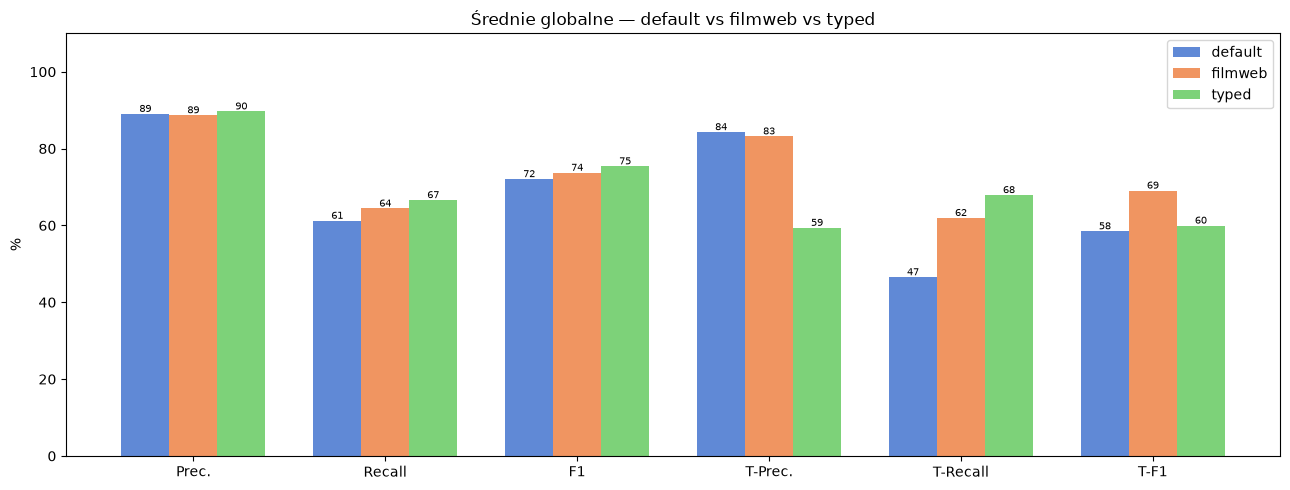

,Prec.,Recall,F1,T-Prec.,T-Recall,T-F1
prompt_label,,,,,,
default,89.0%,61.2%,72.1%,84.3%,46.5%,58.5%
filmweb,88.7%,64.4%,73.7%,83.2%,62.0%,69.1%
typed,89.7%,66.6%,75.4%,59.4%,67.9%,60.0%


In [22]:
prompt_avg = df.groupby("prompt_label")[NUMERIC].mean().reindex(PROMPTS) * 100

x = np.arange(len(NUMERIC))
w = 0.25
xlabels = ["Prec.", "Recall", "F1", "T-Prec.", "T-Recall", "T-F1"]

fig, ax = plt.subplots(figsize=(13, 5))
for i, prompt in enumerate(PROMPTS):
    bars = ax.bar(x + (i-1)*w, prompt_avg.loc[prompt], w,
                  label=prompt, color=PROMPT_COLORS[prompt], alpha=0.87)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{bar.get_height():.0f}", ha="center", fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(xlabels)
ax.set_ylabel("%")
ax.set_ylim(0, 110)
ax.set_title("Średnie globalne — default vs filmweb vs typed")
ax.legend()
fig.tight_layout()
plt.show()

display(
    prompt_avg.rename(columns=dict(zip(NUMERIC, xlabels)))
    .style
    .background_gradient(cmap="RdYlGn", vmin=0, vmax=100)
    .format("{:.1f}%")
)

## Delta względem default (filmweb−default, typed−default)

In [23]:
pivot_mp = avg_mp.pivot_table(index="model_short", columns="prompt_label", values=NUMERIC)
model_order = (
    avg_mp[avg_mp["prompt_label"] == "default"]
    .sort_values("t_precision", ascending=False)["model_short"].tolist()
)

for versus in ["filmweb", "typed"]:
    display(HTML(f"<h4>Δ {versus} − default (pp)</h4>"))
    delta = pd.DataFrame(
        {m: (pivot_mp[m][versus] - pivot_mp[m]["default"]) * 100
         for m in NUMERIC},
        index=pivot_mp.index
    ).reindex(model_order).round(1)
    delta.columns = ["Prec.","Recall","F1","T-Prec.","T-Recall","T-F1"]

    vmax = max(abs(delta.values[~np.isnan(delta.values)])) if delta.notna().any().any() else 20
    display(
        delta.style
        .background_gradient(cmap="RdYlGn", vmin=-vmax, vmax=vmax)
        .format("{:+.1f}")
        .set_table_styles([{"selector": "th", "props": [("white-space", "nowrap")]}])
    )

,Prec.,Recall,F1,T-Prec.,T-Recall,T-F1
model_short,,,,,,
gemma-4-31b-it,-4.4,-2.2,-3.0,+2.2,+10.8,+9.9
gemma-4-26b-a4b-it,-1.8,+4.6,+2.8,+5.3,+30.6,+24.0
mistral-small-3.2-24b-instruct,-0.3,+0.3,-0.3,-1.5,+13.1,+6.6
bielik-11b-v3.0-instruct,+1.4,+5.6,+2.9,+2.9,+17.8,+16.5
qwen3-14b,+7.2,+1.9,+3.0,-20.8,+0.3,-9.1
qwen3-vl-8b,-14.7,-3.0,-8.0,-3.7,+23.7,+13.6
qwen3-32b,+12.0,+10.2,+11.2,+5.4,+10.4,+8.4
qwen3-30b-a3b-instruct-2507,-2.4,+8.0,+4.9,+1.2,+16.8,+14.8


,Prec.,Recall,F1,T-Prec.,T-Recall,T-F1
model_short,,,,,,
gemma-4-31b-it,-5.7,-6.4,-6.3,-23.0,+14.2,+3.0
gemma-4-26b-a4b-it,+3.0,+0.8,+1.6,-23.8,+16.3,+2.3
mistral-small-3.2-24b-instruct,-8.3,+11.2,+3.1,-44.7,+18.0,-19.9
bielik-11b-v3.0-instruct,-0.2,+1.6,-1.3,-12.2,+22.9,+12.2
qwen3-14b,+11.2,+12.4,+12.1,-34.0,+18.6,-6.3
qwen3-vl-8b,-9.3,+14.1,+5.4,-34.1,+38.8,+3.5
qwen3-32b,+10.1,+1.9,+4.9,-8.0,+22.4,+10.7
qwen3-30b-a3b-instruct-2507,+4.2,+7.4,+7.3,-19.5,+19.8,+6.2


## Wykres delta per model (T-F1)

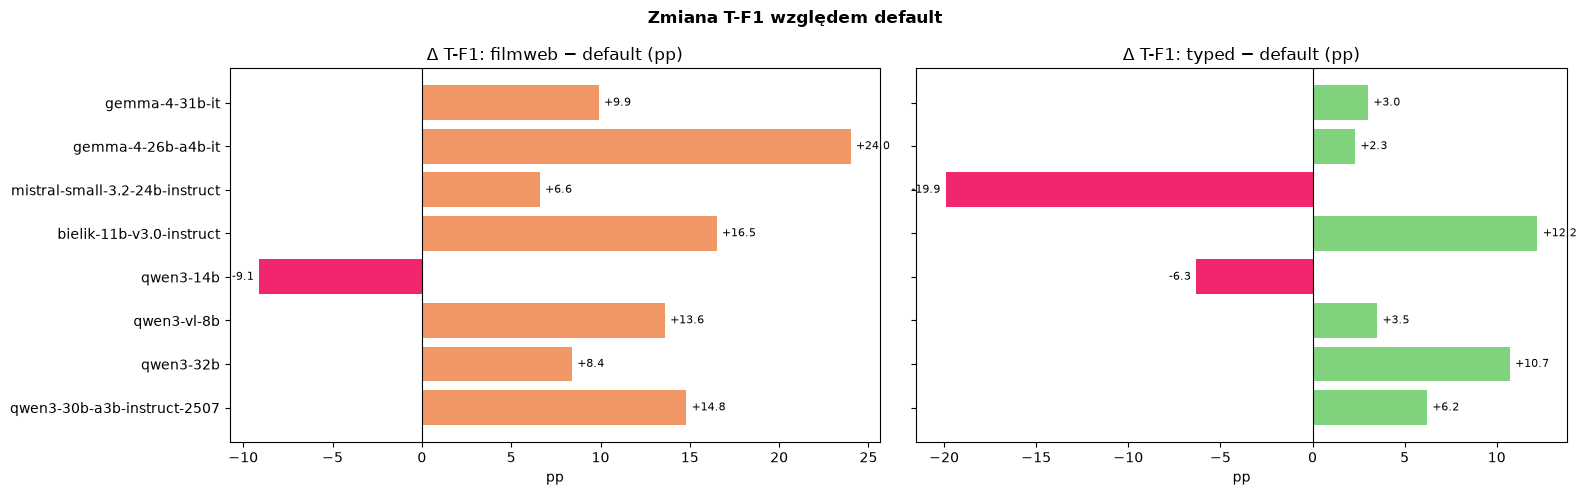

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, versus, color in zip(axes,
                              ["filmweb", "typed"],
                              [PROMPT_COLORS["filmweb"], PROMPT_COLORS["typed"]]):
    deltas = {}
    for m in model_order:
        try:
            d_default = pivot_mp["t_f1"]["default"][m]
            d_versus  = pivot_mp["t_f1"][versus][m]
            deltas[m] = (d_versus - d_default) * 100
        except KeyError:
            deltas[m] = float("nan")

    vals = [deltas[m] for m in model_order[::-1]]
    bar_colors = [color if v >= 0 else "#e05" for v in vals]
    bars = ax.barh(model_order[::-1], vals, color=bar_colors, alpha=0.85)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(val + (0.3 if val >= 0 else -0.3),
                    bar.get_y() + bar.get_height()/2,
                    f"{val:+.1f}", va="center", ha="left" if val >= 0 else "right", fontsize=8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Δ T-F1: {versus} − default (pp)")
    ax.set_xlabel("pp")

fig.suptitle("Zmiana T-F1 względem default", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

## Wykres per model — wszystkie metryki, default vs filmweb vs typed (wartości bezwzględne)

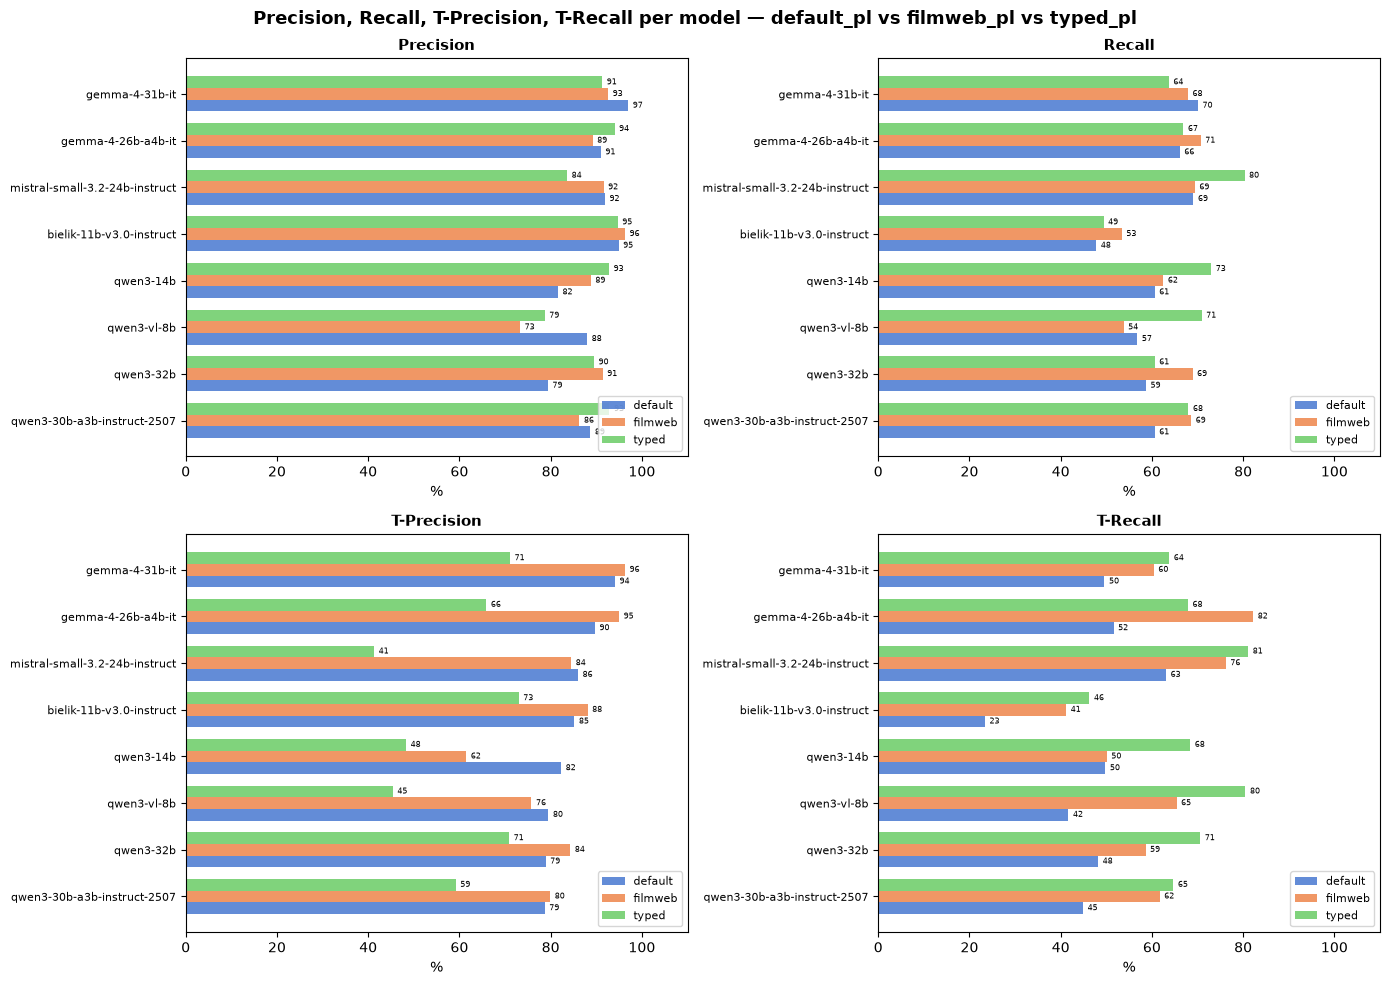

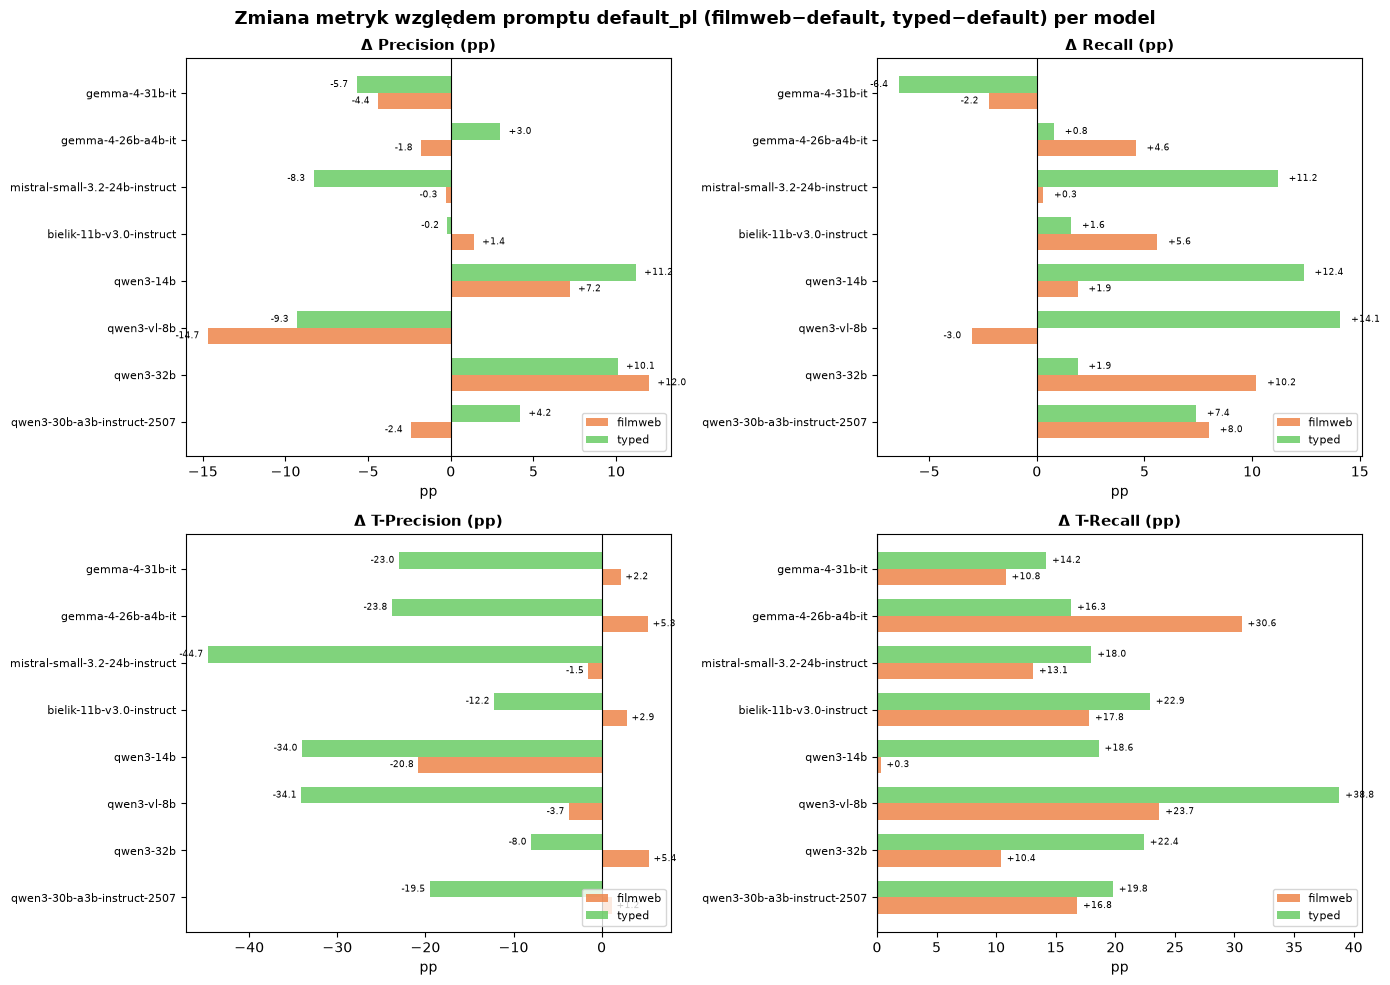

In [25]:
metrics4 = ["precision", "recall", "t_precision", "t_recall"]
mlabels4 = ["Precision", "Recall", "T-Precision", "T-Recall"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

y = np.arange(len(model_order))
h = 0.25

for ax, metric, mlabel in zip(axes, metrics4, mlabels4):
    for i, versus in enumerate(PROMPTS):
        color = PROMPT_COLORS[versus]
        vals = []
        for m in model_order[::-1]:
            try:
                vals.append(pivot_mp[metric][versus][m] * 100)
            except KeyError:
                vals.append(float("nan"))
        offset = (i - 1) * h
        bars = ax.barh(y + offset, vals, h, label=versus, color=color, alpha=0.85)
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
                        f"{val:.0f}", va="center", fontsize=6)
    ax.set_yticks(y)
    ax.set_yticklabels(model_order[::-1], fontsize=8)
    ax.set_title(mlabel, fontsize=11, fontweight="bold")
    ax.set_xlabel("%")
    ax.set_xlim(0, 110)
    ax.legend(fontsize=8, loc="lower right")

fig.suptitle("Precision, Recall, T-Precision, T-Recall per model — default_pl vs filmweb_pl vs typed_pl",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

# ── Delta względem default (pp) — jak poprzednio, dla porównania obok wartości bezwzględnych ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, metric, mlabel in zip(axes, metrics4, mlabels4):
    for i, versus in enumerate(["filmweb", "typed"]):
        color = PROMPT_COLORS[versus]
        deltas = []
        for m in model_order[::-1]:
            try:
                d_default = pivot_mp[metric]["default"][m]
                d_versus = pivot_mp[metric][versus][m]
                deltas.append((d_versus - d_default) * 100)
            except KeyError:
                deltas.append(float("nan"))
        offset = (i - 0.5) * (h * 1.4)
        bars = ax.barh(y + offset, deltas, h * 1.4, label=versus, color=color, alpha=0.85)
        for bar, val in zip(bars, deltas):
            if not np.isnan(val):
                ax.text(val + (0.5 if val >= 0 else -0.5),
                        bar.get_y() + bar.get_height() / 2,
                        f"{val:+.1f}", va="center",
                        ha="left" if val >= 0 else "right", fontsize=6.5)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(model_order[::-1], fontsize=8)
    ax.set_title(f"Δ {mlabel} (pp)", fontsize=11, fontweight="bold")
    ax.set_xlabel("pp")
    ax.legend(fontsize=8, loc="lower right")

fig.suptitle("Zmiana metryk względem promptu default_pl (filmweb−default, typed−default) per model",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()


## Heatmapa: T-F1 per model × artykuł × prompt

In [ ]:
%%sql


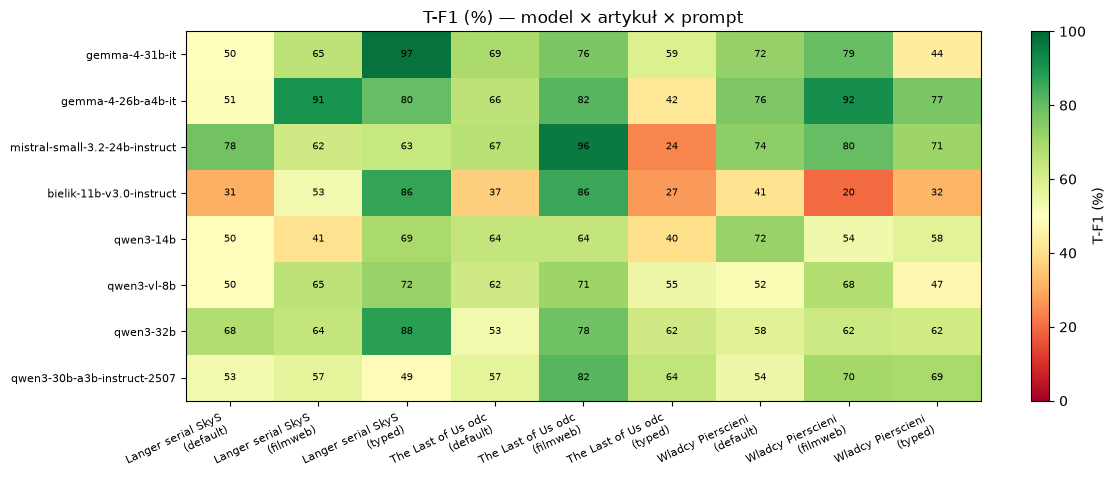

In [26]:
df2 = df.copy()
df2["col"] = df2["title_short"].str[:18] + "\n(" + df2["prompt_label"] + ")"
pivot_heat = (
    df2.groupby(["model_short", "col"])["t_f1"]
    .mean()
    .unstack("col")
    .reindex(model_order)
    * 100
)
# sort columns: group by article
col_order = sorted(pivot_heat.columns,
                   key=lambda c: (c.split("\n")[0], PROMPTS.index(c.split("(")[1].rstrip(")")) if c.split("(")[1].rstrip(")") in PROMPTS else 99))
pivot_heat = pivot_heat[col_order]

fig, ax = plt.subplots(figsize=(max(12, len(pivot_heat.columns)*1.3), max(5, len(model_order)*0.6)))
im = ax.imshow(pivot_heat.values, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(pivot_heat.columns)))
ax.set_xticklabels(pivot_heat.columns, rotation=25, ha="right", fontsize=8)
ax.set_yticks(range(len(model_order)))
ax.set_yticklabels(model_order, fontsize=8)
for i in range(pivot_heat.shape[0]):
    for j in range(pivot_heat.shape[1]):
        val = pivot_heat.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, label="T-F1 (%)")
ax.set_title("T-F1 (%) — model × artykuł × prompt")
fig.tight_layout()
plt.show()

## Najlepszy prompt per model (wg T-F1 i Precision)

In [27]:
best = {}
for metric in ["precision", "f1", "t_precision", "t_f1"]:
    best[metric] = avg_mp.loc[avg_mp.groupby("model_short")[metric].idxmax(), ["model_short", "prompt_label"]].set_index("model_short")["prompt_label"]

best_df = pd.DataFrame(best).reindex(model_order)
best_df.columns = ["Prec.", "F1", "T-Prec.", "T-F1"]

def color_best(val):
    return f"background-color: {PROMPT_COLORS.get(val, '')}"

display(HTML("<p>Który prompt daje najlepszy wynik per model per metryka:</p>"))
display(
    best_df.style
    .map(color_best)
    .set_table_styles([
        {"selector": "td", "props": [("text-align", "center"), ("font-weight", "bold"), ("padding", "6px 14px")]},
        {"selector": "th", "props": [("white-space", "nowrap")]},
    ])
)

# podsumowanie ile razy każdy prompt wygrał
display(HTML("<br><p><b>Liczba wygranych per prompt (łącznie ze wszystkich modeli i metryk):</b></p>"))
display(best_df.apply(pd.Series.value_counts).fillna(0).astype(int)
        .style.background_gradient(cmap="Blues").format("{:d}"))

,Prec.,F1,T-Prec.,T-F1
model_short,,,,
gemma-4-31b-it,default,default,filmweb,filmweb
gemma-4-26b-a4b-it,typed,filmweb,filmweb,filmweb
mistral-small-3.2-24b-instruct,default,typed,default,filmweb
bielik-11b-v3.0-instruct,filmweb,filmweb,filmweb,filmweb
qwen3-14b,typed,typed,default,default
qwen3-vl-8b,default,typed,default,filmweb
qwen3-32b,filmweb,filmweb,filmweb,typed
qwen3-30b-a3b-instruct-2507,typed,typed,filmweb,filmweb


,Prec.,F1,T-Prec.,T-F1
default,3,1,3,1
filmweb,2,3,5,6
typed,3,4,0,1


## Scatter: T-Precision vs T-Recall — per prompt

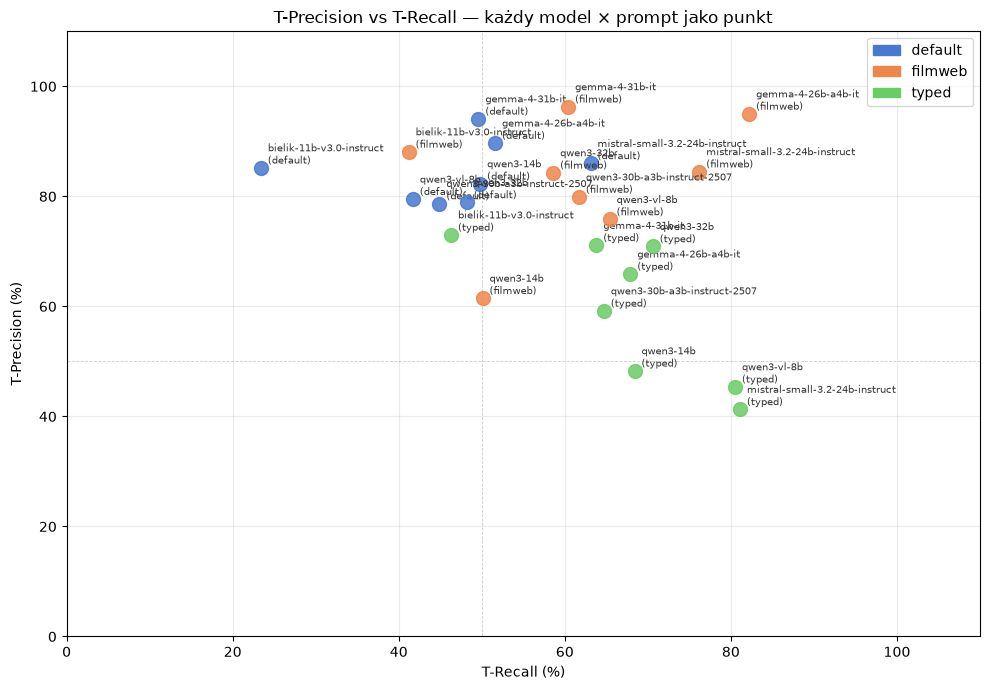

In [28]:
fig, ax = plt.subplots(figsize=(10, 7))

for _, row in avg_mp.iterrows():
    color = PROMPT_COLORS.get(row["prompt_label"], "gray")
    ax.scatter(row["t_recall"]*100, row["t_precision"]*100, color=color, s=100, zorder=3, alpha=0.85)
    ax.annotate(f"{row['model_short']}\n({row['prompt_label']})",
                (row["t_recall"]*100, row["t_precision"]*100),
                textcoords="offset points", xytext=(5, 3), fontsize=7, color="#333")

ax.set_xlabel("T-Recall (%)")
ax.set_ylabel("T-Precision (%)")
ax.set_xlim(0, 110)
ax.set_ylim(0, 110)
ax.axhline(50, color="gray", linestyle="--", linewidth=0.6, alpha=0.4)
ax.axvline(50, color="gray", linestyle="--", linewidth=0.6, alpha=0.4)
ax.set_title("T-Precision vs T-Recall — każdy model × prompt jako punkt")
ax.grid(True, alpha=0.25)
patches = [mpatches.Patch(color=c, label=p) for p, c in PROMPT_COLORS.items()]
ax.legend(handles=patches)
fig.tight_layout()
plt.show()

## Ranking modeli per prompt — sortowanie po Precision i T-Precision

In [29]:
for prompt in PROMPTS:
    sub = avg_mp[avg_mp["prompt_label"] == prompt]
    display(HTML(f"<h3>Prompt: <span style='color:{PROMPT_COLORS[prompt]};font-weight:bold'>{prompt}</span></h3>"))
    for sort_col, sort_label in [("precision", "Precision"), ("t_precision", "T-Precision")]:
        display(HTML(f"<h4>↓ wg {sort_label}</h4>"))
        display(
            sub.sort_values(sort_col, ascending=False)
            .drop(columns="prompt_label")
            .rename(columns={"model_short": "Model",
                             "precision": "Prec.", "recall": "Recall", "f1": "F1",
                             "t_precision": "T-Prec.", "t_recall": "T-Recall", "t_f1": "T-F1"})
            .style
            .background_gradient(subset=["Prec.","Recall","F1","T-Prec.","T-Recall","T-F1"],
                                  cmap="RdYlGn", vmin=0, vmax=1)
            .format({c: "{:.1%}" for c in ["Prec.","Recall","F1","T-Prec.","T-Recall","T-F1"]})
            .set_table_styles([{"selector": "th", "props": [("white-space", "nowrap")]}])
            .hide(axis="index")
        )

Model,Prec.,Recall,F1,T-Prec.,T-Recall,T-F1
gemma-4-31b-it,97.0%,70.1%,81.3%,94.1%,49.6%,63.8%
bielik-11b-v3.0-instruct,94.9%,47.8%,63.3%,85.2%,23.4%,36.3%
mistral-small-3.2-24b-instruct,91.9%,69.1%,78.7%,86.0%,63.1%,72.8%
gemma-4-26b-a4b-it,91.0%,66.1%,76.1%,89.7%,51.6%,64.1%
qwen3-30b-a3b-instruct-2507,88.7%,60.6%,71.3%,78.7%,44.9%,54.7%
qwen3-vl-8b,88.0%,56.8%,69.0%,79.5%,41.7%,54.5%
qwen3-14b,81.6%,60.6%,69.5%,82.3%,49.8%,62.0%
qwen3-32b,79.4%,58.7%,67.3%,78.9%,48.2%,59.8%


Model,Prec.,Recall,F1,T-Prec.,T-Recall,T-F1
gemma-4-31b-it,97.0%,70.1%,81.3%,94.1%,49.6%,63.8%
gemma-4-26b-a4b-it,91.0%,66.1%,76.1%,89.7%,51.6%,64.1%
mistral-small-3.2-24b-instruct,91.9%,69.1%,78.7%,86.0%,63.1%,72.8%
bielik-11b-v3.0-instruct,94.9%,47.8%,63.3%,85.2%,23.4%,36.3%
qwen3-14b,81.6%,60.6%,69.5%,82.3%,49.8%,62.0%
qwen3-vl-8b,88.0%,56.8%,69.0%,79.5%,41.7%,54.5%
qwen3-32b,79.4%,58.7%,67.3%,78.9%,48.2%,59.8%
qwen3-30b-a3b-instruct-2507,88.7%,60.6%,71.3%,78.7%,44.9%,54.7%


Model,Prec.,Recall,F1,T-Prec.,T-Recall,T-F1
bielik-11b-v3.0-instruct,96.3%,53.4%,66.2%,88.1%,41.2%,52.8%
gemma-4-31b-it,92.6%,67.9%,78.3%,96.3%,60.4%,73.7%
mistral-small-3.2-24b-instruct,91.6%,69.4%,78.4%,84.5%,76.2%,79.4%
qwen3-32b,91.4%,68.9%,78.5%,84.3%,58.6%,68.2%
gemma-4-26b-a4b-it,89.2%,70.7%,78.9%,95.0%,82.2%,88.1%
qwen3-14b,88.8%,62.5%,72.5%,61.5%,50.1%,52.9%
qwen3-30b-a3b-instruct-2507,86.3%,68.6%,76.2%,79.9%,61.7%,69.5%
qwen3-vl-8b,73.3%,53.8%,61.0%,75.8%,65.4%,68.1%


Model,Prec.,Recall,F1,T-Prec.,T-Recall,T-F1
gemma-4-31b-it,92.6%,67.9%,78.3%,96.3%,60.4%,73.7%
gemma-4-26b-a4b-it,89.2%,70.7%,78.9%,95.0%,82.2%,88.1%
bielik-11b-v3.0-instruct,96.3%,53.4%,66.2%,88.1%,41.2%,52.8%
mistral-small-3.2-24b-instruct,91.6%,69.4%,78.4%,84.5%,76.2%,79.4%
qwen3-32b,91.4%,68.9%,78.5%,84.3%,58.6%,68.2%
qwen3-30b-a3b-instruct-2507,86.3%,68.6%,76.2%,79.9%,61.7%,69.5%
qwen3-vl-8b,73.3%,53.8%,61.0%,75.8%,65.4%,68.1%
qwen3-14b,88.8%,62.5%,72.5%,61.5%,50.1%,52.9%


Model,Prec.,Recall,F1,T-Prec.,T-Recall,T-F1
bielik-11b-v3.0-instruct,94.7%,49.4%,62.0%,73.0%,46.3%,48.5%
gemma-4-26b-a4b-it,94.0%,66.9%,77.7%,65.9%,67.9%,66.4%
qwen3-30b-a3b-instruct-2507,92.9%,68.0%,78.6%,59.2%,64.7%,60.9%
qwen3-14b,92.8%,73.0%,81.6%,48.3%,68.4%,55.7%
gemma-4-31b-it,91.3%,63.7%,75.0%,71.1%,63.8%,66.8%
qwen3-32b,89.5%,60.6%,72.2%,70.9%,70.6%,70.5%
mistral-small-3.2-24b-instruct,83.6%,80.3%,81.8%,41.3%,81.1%,52.9%
qwen3-vl-8b,78.7%,70.9%,74.4%,45.4%,80.5%,58.0%


Model,Prec.,Recall,F1,T-Prec.,T-Recall,T-F1
bielik-11b-v3.0-instruct,94.7%,49.4%,62.0%,73.0%,46.3%,48.5%
gemma-4-31b-it,91.3%,63.7%,75.0%,71.1%,63.8%,66.8%
qwen3-32b,89.5%,60.6%,72.2%,70.9%,70.6%,70.5%
gemma-4-26b-a4b-it,94.0%,66.9%,77.7%,65.9%,67.9%,66.4%
qwen3-30b-a3b-instruct-2507,92.9%,68.0%,78.6%,59.2%,64.7%,60.9%
qwen3-14b,92.8%,73.0%,81.6%,48.3%,68.4%,55.7%
qwen3-vl-8b,78.7%,70.9%,74.4%,45.4%,80.5%,58.0%
mistral-small-3.2-24b-instruct,83.6%,80.3%,81.8%,41.3%,81.1%,52.9%


## Wnioski i selekcja 4 najlepszych modeli

In [30]:
# ── T-F1 per model × prompt (dane do wniosków) ───────────────────────────────
tf1 = avg_mp.pivot_table(index="model_short", columns="prompt_label", values="t_f1") * 100
tp  = avg_mp.pivot_table(index="model_short", columns="prompt_label", values="t_precision") * 100
tr  = avg_mp.pivot_table(index="model_short", columns="prompt_label", values="t_recall") * 100

display(HTML("<h4>T-F1 per model × prompt (%)</h4>"))
display(
    tf1.reindex(model_order)[PROMPTS]
    .style
    .background_gradient(cmap="RdYlGn", vmin=0, vmax=100)
    .format("{:.1f}")
    .highlight_max(axis=1, props="font-weight:bold;border:2px solid #333")
)

# ── delta filmweb−default i typed−default ────────────────────────────────────
delta_fw = (tf1["filmweb"] - tf1["default"]).reindex(model_order).round(1)
delta_ty = (tf1["typed"]   - tf1["default"]).reindex(model_order).round(1)

delta_summary = pd.DataFrame({
    "T-F1 default": tf1["default"].reindex(model_order).round(1),
    "T-F1 filmweb": tf1["filmweb"].reindex(model_order).round(1),
    "T-F1 typed":   tf1["typed"].reindex(model_order).round(1),
    "Δ filmweb":    delta_fw,
    "Δ typed":      delta_ty,
    "Najlepszy prompt": tf1[PROMPTS].reindex(model_order).idxmax(axis=1),
})

display(HTML("<h4>Delta T-F1 względem default</h4>"))
display(
    delta_summary.style
    .background_gradient(subset=["T-F1 default","T-F1 filmweb","T-F1 typed"], cmap="RdYlGn", vmin=0, vmax=100)
    .background_gradient(subset=["Δ filmweb","Δ typed"], cmap="RdYlGn", vmin=-30, vmax=30)
    .format({c: "{:.1f}" for c in delta_summary.columns if c != "Najlepszy prompt"})
    .set_table_styles([{"selector": "th", "props": [("white-space", "nowrap")]}])
)

# ── TOP 4 modele wg najlepszego T-F1 (z dowolnego promptu) ───────────────────
best_tf1 = tf1[PROMPTS].max(axis=1).sort_values(ascending=False)
display(HTML("<h4>Ranking wg najlepszego osiągalnego T-F1</h4>"))
display(best_tf1.rename("max T-F1 (%)").to_frame().style
        .background_gradient(cmap="RdYlGn", vmin=0, vmax=100).format("{:.1f}"))

prompt_label,default,filmweb,typed
model_short,,,
gemma-4-31b-it,63.8,73.7,66.8
gemma-4-26b-a4b-it,64.1,88.1,66.4
mistral-small-3.2-24b-instruct,72.8,79.4,52.9
bielik-11b-v3.0-instruct,36.3,52.8,48.5
qwen3-14b,62.0,52.9,55.7
qwen3-vl-8b,54.5,68.1,58.0
qwen3-32b,59.8,68.2,70.5
qwen3-30b-a3b-instruct-2507,54.7,69.5,60.9


,T-F1 default,T-F1 filmweb,T-F1 typed,Δ filmweb,Δ typed,Najlepszy prompt
model_short,,,,,,
gemma-4-31b-it,63.8,73.7,66.8,9.9,3.0,filmweb
gemma-4-26b-a4b-it,64.1,88.1,66.4,24.0,2.3,filmweb
mistral-small-3.2-24b-instruct,72.8,79.4,52.9,6.6,-19.9,filmweb
bielik-11b-v3.0-instruct,36.3,52.8,48.5,16.5,12.2,filmweb
qwen3-14b,62.0,52.9,55.7,-9.1,-6.3,default
qwen3-vl-8b,54.5,68.1,58.0,13.6,3.5,filmweb
qwen3-32b,59.8,68.2,70.5,8.4,10.7,typed
qwen3-30b-a3b-instruct-2507,54.7,69.5,60.9,14.8,6.2,filmweb


,max T-F1 (%)
model_short,
gemma-4-26b-a4b-it,88.1
mistral-small-3.2-24b-instruct,79.4
gemma-4-31b-it,73.7
qwen3-32b,70.5
qwen3-30b-a3b-instruct-2507,69.5
qwen3-vl-8b,68.1
qwen3-14b,62.0
bielik-11b-v3.0-instruct,52.8


### Wnioski

**1. filmweb wygrywa dla 6 z 8 modeli**

Prompt `filmweb_pl` daje najwyższy T-F1 dla zdecydowanej większości modeli. Największe skoki:
- **gemma-4-26b**: default 64.1 → filmweb **88.1** (+24 pp) — wynik absolutnie wyróżniający się
- **qwen3-vl-8b**: default 54.5 → filmweb **68.1** (+13.6 pp)
- **bielik-11b**: default 36.3 → filmweb **52.8** (+16.5 pp)
- **qwen3-30b**: default 54.6 → filmweb **69.6** (+15 pp)
- **gemma-4-31b**: default 63.8 → filmweb **73.7** (+9.9 pp)
- **mistral-small-24b**: default 72.8 → filmweb **79.4** (+6.6 pp)

**2. typed niszczy T-Precision dla większości modeli**

Prompt `typed_pl` powoduje dramatyczny spadek T-Precision przy jednoczesnym wzroście T-Recall — modele ekstraktorują więcej relacji, ale semantycznie nie pokrywają się z referencją:
- mistral-small-24b: T-Prec 86.0 → **41.3** (-44.7 pp!)
- qwen3-14b: T-Prec 82.3 → **48.3** (-34 pp)
- qwen3-vl-8b: T-Prec 79.5 → **45.4** (-34.1 pp)

Jedyny model gdzie typed działa przyzwoicie: **qwen3-32b** (T-F1 typed=70.5 vs filmweb=68.2).

**3. qwen3-14b i qwen3-vl-8b — odwrotna reakcja na filmweb**

Oba modele Qwen tracą na filmweb w T-Precision (qwen3-14b: 82.3→61.5, qwen3-vl-8b: 79.5→75.8), co sugeruje że filmweb prompt jest zbyt dziedzinowy i wprowadza szum dla modeli które nie znają kontekstu filmowego.

**4. Selekcja 4 modeli do finalnych badań**

Na podstawie najlepszego osiągalnego T-F1 (z optymalnym promptem dla każdego modelu):

| Model | Najlepszy prompt | T-F1 |
|---|---|---|
| **gemma-4-26b** | filmweb | **88.1%** |
| **mistral-small-24b** | filmweb | **79.4%** |
| **gemma-4-31b** | filmweb | **73.7%** |
| **qwen3-30b** | filmweb | **69.6%** |

Wszyscy czterej najlepsi modele mają optymalny prompt **filmweb** — wniosek jest jednoznaczny. Dalsze badania prowadzone na tych 4 modelach z promptem `filmweb_pl/new_graph`.

---\n## Analiza szczegółowa — 4 wybrane modele\n\n`gemma-4-26b-a4b-it` · `gemma-4-31b-it` · `mistral-small-3.2-24b-instruct` · `qwen3-32b`

In [31]:
TOP4 = ["gemma-4-26b-a4b-it", "gemma-4-31b-it", "mistral-small-3.2-24b-instruct", "qwen3-32b"]
TOP4_BEST_PROMPT = {
    "gemma-4-26b-a4b-it":             "filmweb",
    "gemma-4-31b-it":                 "filmweb",
    "mistral-small-3.2-24b-instruct": "filmweb",
    "qwen3-32b":                       "typed",
}

df4 = df[df["model_short"].isin(TOP4)].copy()
avg4 = avg_mp[avg_mp["model_short"].isin(TOP4)].copy()

# ── 1. Tabela średnich — 3 prompty, 2 sorty ──────────────────────────────────
for sort_col, sort_label in [("precision", "Precision"), ("t_precision", "T-Precision")]:
    display(HTML(f"<h4>Średnie per model × prompt — ranking wg {sort_label}</h4>"))
    display(
        avg4.sort_values(sort_col, ascending=False)
        .rename(columns={"model_short": "Model", "prompt_label": "Prompt",
                         "precision": "Prec.", "recall": "Recall", "f1": "F1",
                         "t_precision": "T-Prec.", "t_recall": "T-Recall", "t_f1": "T-F1"})
        .style
        .apply(color_prompt, axis=1)
        .background_gradient(subset=["Prec.","Recall","F1","T-Prec.","T-Recall","T-F1"],
                              cmap="RdYlGn", vmin=0, vmax=1)
        .format({c: "{:.1%}" for c in ["Prec.","Recall","F1","T-Prec.","T-Recall","T-F1"]})
        .set_table_styles([{"selector": "th", "props": [("white-space", "nowrap")]}])
        .hide(axis="index")
    )

Model,Prompt,Prec.,Recall,F1,T-Prec.,T-Recall,T-F1
gemma-4-31b-it,default,97.0%,70.1%,81.3%,94.1%,49.6%,63.8%
gemma-4-26b-a4b-it,typed,94.0%,66.9%,77.7%,65.9%,67.9%,66.4%
gemma-4-31b-it,filmweb,92.6%,67.9%,78.3%,96.3%,60.4%,73.7%
mistral-small-3.2-24b-instruct,default,91.9%,69.1%,78.7%,86.0%,63.1%,72.8%
mistral-small-3.2-24b-instruct,filmweb,91.6%,69.4%,78.4%,84.5%,76.2%,79.4%
qwen3-32b,filmweb,91.4%,68.9%,78.5%,84.3%,58.6%,68.2%
gemma-4-31b-it,typed,91.3%,63.7%,75.0%,71.1%,63.8%,66.8%
gemma-4-26b-a4b-it,default,91.0%,66.1%,76.1%,89.7%,51.6%,64.1%
qwen3-32b,typed,89.5%,60.6%,72.2%,70.9%,70.6%,70.5%
gemma-4-26b-a4b-it,filmweb,89.2%,70.7%,78.9%,95.0%,82.2%,88.1%


Model,Prompt,Prec.,Recall,F1,T-Prec.,T-Recall,T-F1
gemma-4-31b-it,filmweb,92.6%,67.9%,78.3%,96.3%,60.4%,73.7%
gemma-4-26b-a4b-it,filmweb,89.2%,70.7%,78.9%,95.0%,82.2%,88.1%
gemma-4-31b-it,default,97.0%,70.1%,81.3%,94.1%,49.6%,63.8%
gemma-4-26b-a4b-it,default,91.0%,66.1%,76.1%,89.7%,51.6%,64.1%
mistral-small-3.2-24b-instruct,default,91.9%,69.1%,78.7%,86.0%,63.1%,72.8%
mistral-small-3.2-24b-instruct,filmweb,91.6%,69.4%,78.4%,84.5%,76.2%,79.4%
qwen3-32b,filmweb,91.4%,68.9%,78.5%,84.3%,58.6%,68.2%
qwen3-32b,default,79.4%,58.7%,67.3%,78.9%,48.2%,59.8%
gemma-4-31b-it,typed,91.3%,63.7%,75.0%,71.1%,63.8%,66.8%
qwen3-32b,typed,89.5%,60.6%,72.2%,70.9%,70.6%,70.5%


## Porównanie promptów — średnie TYLKO dla 4 wybranych modeli (odpowiednik Tabeli 4.7 w pracy)

In [ ]:
metrics4b = ["precision", "recall", "t_precision", "t_recall"]
xlabels4 = ["Precision", "Recall", "T-Precision", "T-Recall"]

avg4_prompt = avg4.groupby("prompt_label")[metrics4b].mean().reindex(PROMPTS) * 100

x = np.arange(len(metrics4b))
w = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, prompt in enumerate(PROMPTS):
    bars = ax.bar(x + (i - 1) * w, avg4_prompt.loc[prompt], w,
                  label=prompt, color=PROMPT_COLORS[prompt], alpha=0.87)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{bar.get_height():.0f}", ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(xlabels4)
ax.set_ylabel("%")
ax.set_ylim(0, 110)
ax.set_title("Tylko 4 wybrane modele: gemma-4-26b-a4b-it, gemma-4-31b-it, mistral-small-3.2-24b-instruct, qwen3-32b",
             fontsize=10)
ax.legend()
fig.tight_layout()
plt.show()

display(
    avg4_prompt.rename(columns=dict(zip(metrics4b, xlabels4)))
    .style
    .background_gradient(cmap="RdYlGn", vmin=0, vmax=100)
    .format("{:.1f}%")
)


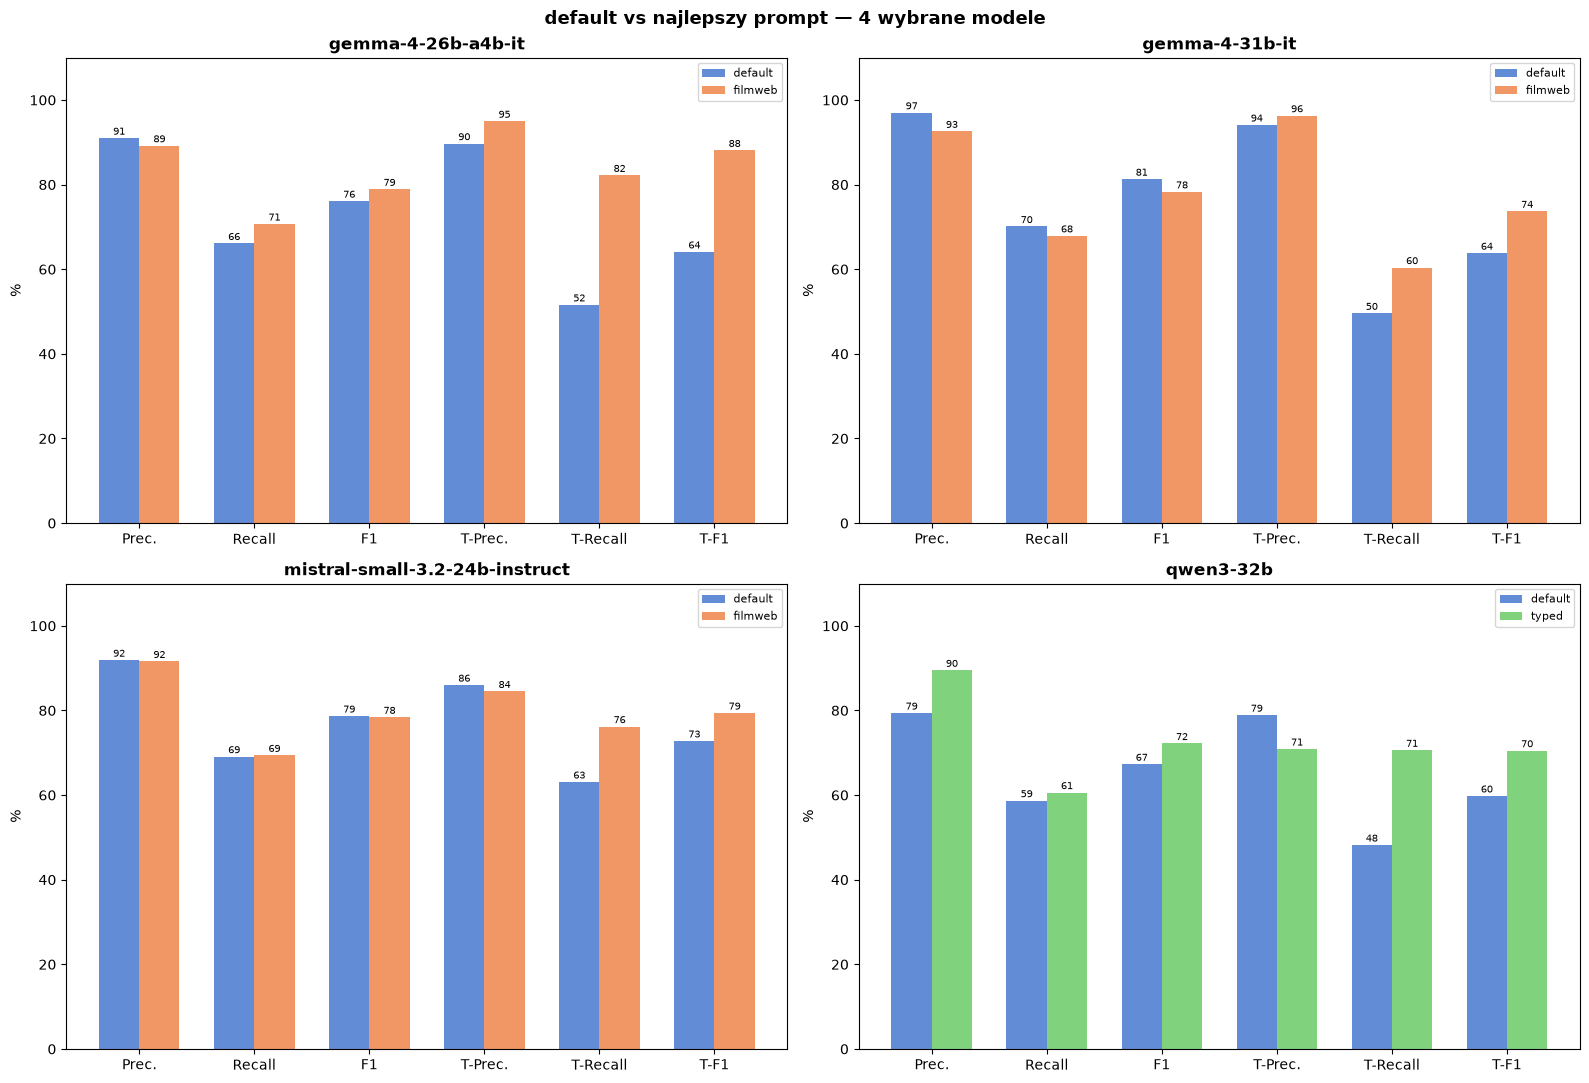

In [32]:
# ── 2. Wykres: default vs best prompt — wszystkie metryki ────────────────────
metrics6 = ["precision", "recall", "f1", "t_precision", "t_recall", "t_f1"]
mlabels6 = ["Prec.", "Recall", "F1", "T-Prec.", "T-Recall", "T-F1"]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax, model in zip(axes, TOP4):
    best_p = TOP4_BEST_PROMPT[model]
    sub_def  = avg4[(avg4["model_short"]==model) & (avg4["prompt_label"]=="default")].iloc[0]
    sub_best = avg4[(avg4["model_short"]==model) & (avg4["prompt_label"]==best_p)].iloc[0]

    x = np.arange(len(metrics6))
    w = 0.35
    b1 = ax.bar(x - w/2, [sub_def[m]*100  for m in metrics6], w,
                label="default", color=PROMPT_COLORS["default"], alpha=0.85)
    b2 = ax.bar(x + w/2, [sub_best[m]*100 for m in metrics6], w,
                label=best_p,   color=PROMPT_COLORS[best_p],   alpha=0.85)

    for bar in list(b1) + list(b2):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
                f"{bar.get_height():.0f}", ha="center", fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(mlabels6)
    ax.set_ylim(0, 110)
    ax.set_ylabel("%")
    ax.set_title(model, fontweight="bold")
    ax.legend(fontsize=8)

fig.suptitle("default vs najlepszy prompt — 4 wybrane modele", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

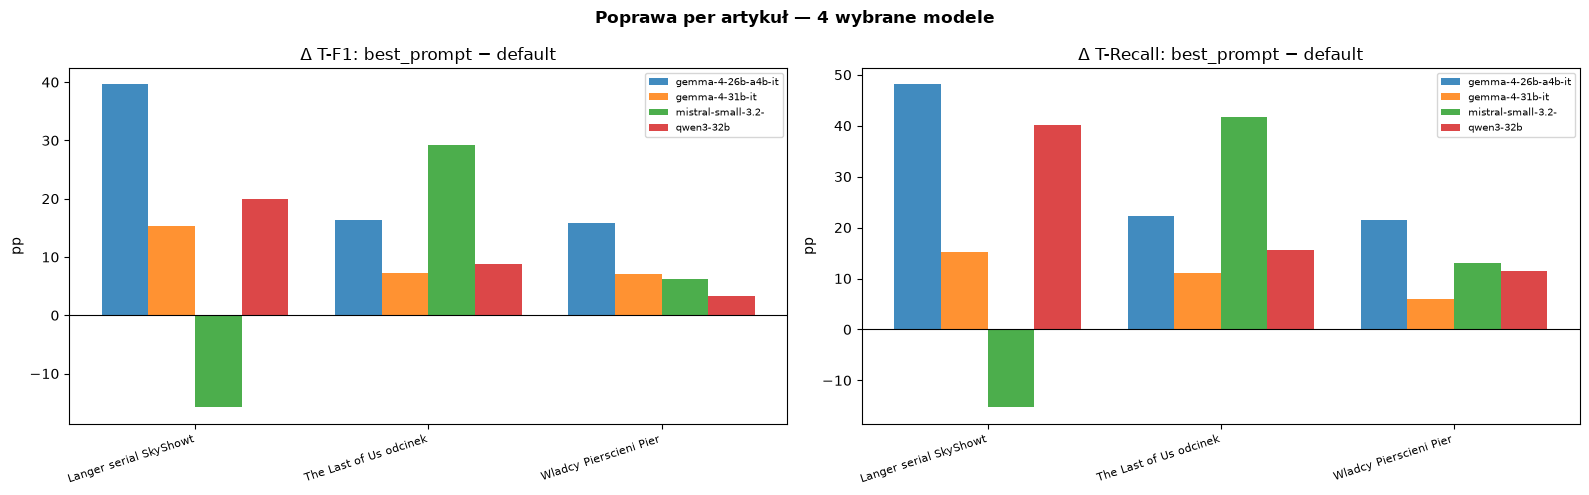

In [33]:
# ── 3. Delta default→best: T-F1 i T-Recall per artykuł ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, mlabel in zip(axes, ["t_f1", "t_recall"], ["T-F1", "T-Recall"]):
    articles = sorted(df4["title_short"].unique())
    x = np.arange(len(articles))
    w = 0.2

    for i, model in enumerate(TOP4):
        best_p = TOP4_BEST_PROMPT[model]
        deltas = []
        for art in articles:
            row_def  = df4[(df4["model_short"]==model)&(df4["title_short"]==art)&(df4["prompt_label"]=="default")]
            row_best = df4[(df4["model_short"]==model)&(df4["title_short"]==art)&(df4["prompt_label"]==best_p)]
            if len(row_def) and len(row_best):
                deltas.append((row_best.iloc[0][metric] - row_def.iloc[0][metric]) * 100)
            else:
                deltas.append(float("nan"))
        ax.bar(x + (i-1.5)*w, deltas, w, label=model[:18], alpha=0.85)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([a[:22] for a in articles], rotation=18, ha="right", fontsize=8)
    ax.set_ylabel("pp")
    ax.set_title(f"Δ {mlabel}: best_prompt − default")
    ax.legend(fontsize=7)

fig.suptitle("Poprawa per artykuł — 4 wybrane modele", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

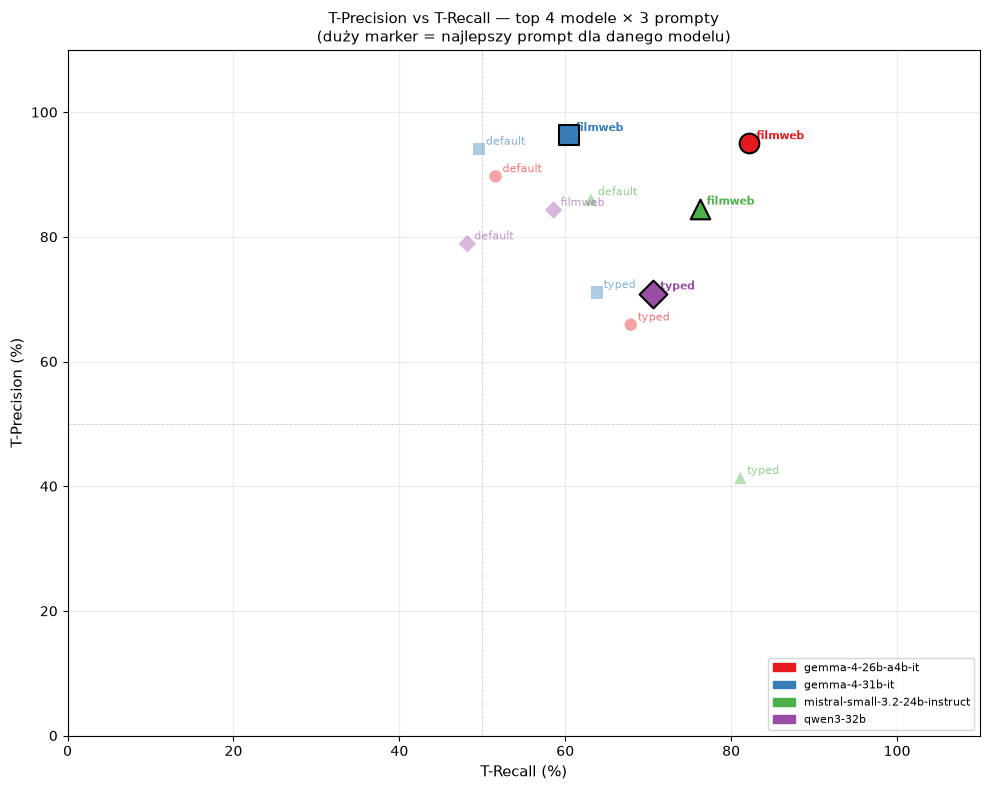

In [34]:
# ── 4. Scatter T-Prec vs T-Recall — tylko top 4, wszystkie 3 prompty ─────────
fig, ax = plt.subplots(figsize=(10, 8))

markers = {"gemma-4-26b-a4b-it": "o", "gemma-4-31b-it": "s",
           "mistral-small-3.2-24b-instruct": "^", "qwen3-32b": "D"}
model_colors = {"gemma-4-26b-a4b-it": "#e41a1c", "gemma-4-31b-it": "#377eb8",
                "mistral-small-3.2-24b-instruct": "#4daf4a", "qwen3-32b": "#984ea3"}

for _, row in avg4.iterrows():
    m, p = row["model_short"], row["prompt_label"]
    is_best = (TOP4_BEST_PROMPT[m] == p)
    ax.scatter(row["t_recall"]*100, row["t_precision"]*100,
               marker=markers[m], color=model_colors[m],
               s=200 if is_best else 80,
               zorder=4 if is_best else 3,
               alpha=1.0 if is_best else 0.4,
               edgecolors="black" if is_best else "none", linewidth=1.5)
    ax.annotate(p, (row["t_recall"]*100, row["t_precision"]*100),
                textcoords="offset points", xytext=(5, 3), fontsize=8,
                color=model_colors[m], alpha=1.0 if is_best else 0.6,
                fontweight="bold" if is_best else "normal")

# legenda modeli
model_patches = [mpatches.Patch(color=model_colors[m], label=m) for m in TOP4]
ax.legend(handles=model_patches, fontsize=8, loc="lower right")
ax.set_xlabel("T-Recall (%)", fontsize=11)
ax.set_ylabel("T-Precision (%)", fontsize=11)
ax.set_xlim(0, 110); ax.set_ylim(0, 110)
ax.axhline(50, color="gray", linestyle="--", linewidth=0.6, alpha=0.4)
ax.axvline(50, color="gray", linestyle="--", linewidth=0.6, alpha=0.4)
ax.set_title("T-Precision vs T-Recall — top 4 modele × 3 prompty\n(duży marker = najlepszy prompt dla danego modelu)", fontsize=11)
ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

In [35]:
# ── 5. Pełna tabela per artykuł — tylko top 4, posortowane po precision i t_precision ──
for sort_col, sort_label in [("precision", "Precision"), ("t_precision", "T-Precision")]:
    display(HTML(f"<h4>Sortowanie wg {sort_label}</h4>"))
    for article, group in df4.groupby("title_short"):
        display(HTML(f"<b>{article}</b>"))
        display(
            group[DISPLAY_COLS]
            .sort_values(sort_col, ascending=False)
            .rename(columns=RENAME)
            .style
            .apply(color_prompt, axis=1)
            .background_gradient(subset=GRAD, cmap="RdYlGn", vmin=0, vmax=1)
            .format(FMT)
            .set_table_styles([{"selector": "th", "props": [("white-space", "nowrap")]}])
            .hide(axis="index")
        )

Model,Prompt,Prec.,Recall,F1,Hall.,Miss.,T-Prec.,T-Recall,T-F1,T-Hall.,T-Miss.
gemma-4-26b-a4b-it,filmweb,100.0%,78.4%,87.9%,0 | 29,8 | 37,100.0%,82.9%,90.7%,0 | 29,6 | 35
qwen3-32b,filmweb,100.0%,81.8%,90.0%,0 | 18,4 | 22,94.4%,48.6%,64.2%,1 | 18,18 | 35
mistral-small-3.2-24b-instruct,filmweb,100.0%,59.0%,74.2%,0 | 23,16 | 39,78.3%,51.4%,62.1%,5 | 23,17 | 35
gemma-4-31b-it,filmweb,100.0%,81.0%,89.5%,0 | 17,4 | 21,100.0%,48.6%,65.4%,0 | 17,18 | 35
mistral-small-3.2-24b-instruct,default,97.9%,64.8%,78.0%,1 | 47,25 | 71,93.6%,66.7%,77.9%,3 | 47,22 | 66
gemma-4-26b-a4b-it,default,95.8%,56.1%,70.8%,1 | 24,18 | 41,95.8%,34.8%,51.1%,1 | 24,43 | 66
qwen3-32b,typed,95.5%,70.0%,80.8%,1 | 22,9 | 30,81.8%,94.7%,87.8%,4 | 22,1 | 19
gemma-4-26b-a4b-it,typed,93.8%,55.6%,69.8%,1 | 16,12 | 27,87.5%,73.7%,80.0%,2 | 16,5 | 19
gemma-4-31b-it,default,90.9%,62.5%,74.1%,2 | 22,12 | 32,100.0%,33.3%,50.0%,0 | 22,44 | 66
mistral-small-3.2-24b-instruct,typed,90.2%,84.1%,87.0%,4 | 41,7 | 44,46.3%,100.0%,63.3%,22 | 41,0 | 19


Model,Prompt,Prec.,Recall,F1,Hall.,Miss.,T-Prec.,T-Recall,T-F1,T-Hall.,T-Miss.
gemma-4-31b-it,typed,100.0%,66.7%,80.0%,0 | 12,6 | 18,66.7%,53.3%,59.3%,4 | 12,7 | 15
gemma-4-31b-it,default,100.0%,71.0%,83.0%,0 | 22,9 | 31,90.9%,55.6%,69.0%,2 | 22,16 | 36
gemma-4-26b-a4b-it,typed,94.4%,63.0%,75.6%,1 | 18,10 | 27,38.9%,46.7%,42.4%,11 | 18,8 | 15
qwen3-32b,filmweb,90.9%,66.7%,76.9%,1 | 11,5 | 15,81.8%,75.0%,78.3%,2 | 11,3 | 12
gemma-4-26b-a4b-it,default,86.4%,63.3%,73.1%,3 | 22,11 | 30,86.4%,52.8%,65.5%,3 | 22,17 | 36
mistral-small-3.2-24b-instruct,filmweb,84.6%,68.8%,75.9%,2 | 13,5 | 16,92.3%,100.0%,96.0%,1 | 13,0 | 12
qwen3-32b,typed,78.6%,50.0%,61.1%,3 | 14,11 | 22,64.3%,60.0%,62.1%,5 | 14,6 | 15
gemma-4-31b-it,filmweb,77.8%,53.8%,63.6%,2 | 9,6 | 13,88.9%,66.7%,76.2%,1 | 9,4 | 12
mistral-small-3.2-24b-instruct,default,77.8%,63.6%,70.0%,6 | 27,12 | 33,77.8%,58.3%,66.7%,6 | 27,15 | 36
mistral-small-3.2-24b-instruct,typed,75.0%,81.8%,78.3%,15 | 60,10 | 55,15.0%,60.0%,24.0%,51 | 60,6 | 15


Model,Prompt,Prec.,Recall,F1,Hall.,Miss.,T-Prec.,T-Recall,T-F1,T-Hall.,T-Miss.
gemma-4-31b-it,filmweb,100.0%,69.0%,81.7%,0 | 29,13 | 42,100.0%,65.9%,79.4%,0 | 29,15 | 44
gemma-4-31b-it,default,100.0%,76.7%,86.8%,0 | 46,14 | 60,91.3%,60.0%,72.4%,4 | 46,28 | 70
mistral-small-3.2-24b-instruct,default,100.0%,78.8%,88.1%,0 | 52,14 | 66,86.5%,64.3%,73.8%,7 | 52,25 | 70
gemma-4-26b-a4b-it,filmweb,97.6%,80.0%,87.9%,1 | 41,10 | 50,95.1%,88.6%,91.7%,2 | 41,5 | 44
qwen3-32b,typed,94.4%,61.8%,74.7%,2 | 36,21 | 55,66.7%,57.1%,61.5%,12 | 36,18 | 42
gemma-4-26b-a4b-it,typed,93.9%,82.1%,87.6%,3 | 49,10 | 56,71.4%,83.3%,76.9%,14 | 49,7 | 42
qwen3-32b,default,92.5%,60.7%,73.3%,3 | 40,24 | 61,80.0%,45.7%,58.2%,8 | 40,38 | 70
gemma-4-26b-a4b-it,default,90.7%,79.0%,84.4%,5 | 54,13 | 62,87.0%,67.1%,75.8%,7 | 54,23 | 70
mistral-small-3.2-24b-instruct,filmweb,90.2%,80.4%,85.0%,4 | 41,9 | 46,82.9%,77.3%,80.0%,7 | 41,10 | 44
mistral-small-3.2-24b-instruct,typed,85.7%,75.0%,80.0%,8 | 56,16 | 64,62.5%,83.3%,71.4%,21 | 56,7 | 42


Model,Prompt,Prec.,Recall,F1,Hall.,Miss.,T-Prec.,T-Recall,T-F1,T-Hall.,T-Miss.
gemma-4-26b-a4b-it,filmweb,100.0%,78.4%,87.9%,0 | 29,8 | 37,100.0%,82.9%,90.7%,0 | 29,6 | 35
gemma-4-31b-it,filmweb,100.0%,81.0%,89.5%,0 | 17,4 | 21,100.0%,48.6%,65.4%,0 | 17,18 | 35
gemma-4-31b-it,default,90.9%,62.5%,74.1%,2 | 22,12 | 32,100.0%,33.3%,50.0%,0 | 22,44 | 66
gemma-4-26b-a4b-it,default,95.8%,56.1%,70.8%,1 | 24,18 | 41,95.8%,34.8%,51.1%,1 | 24,43 | 66
gemma-4-31b-it,typed,90.0%,66.7%,76.6%,2 | 20,9 | 27,95.0%,100.0%,97.4%,1 | 20,0 | 19
qwen3-32b,filmweb,100.0%,81.8%,90.0%,0 | 18,4 | 22,94.4%,48.6%,64.2%,1 | 18,18 | 35
mistral-small-3.2-24b-instruct,default,97.9%,64.8%,78.0%,1 | 47,25 | 71,93.6%,66.7%,77.9%,3 | 47,22 | 66
qwen3-32b,default,75.0%,63.8%,68.9%,10 | 40,17 | 47,90.0%,54.5%,67.9%,4 | 40,30 | 66
gemma-4-26b-a4b-it,typed,93.8%,55.6%,69.8%,1 | 16,12 | 27,87.5%,73.7%,80.0%,2 | 16,5 | 19
qwen3-32b,typed,95.5%,70.0%,80.8%,1 | 22,9 | 30,81.8%,94.7%,87.8%,4 | 22,1 | 19


Model,Prompt,Prec.,Recall,F1,Hall.,Miss.,T-Prec.,T-Recall,T-F1,T-Hall.,T-Miss.
mistral-small-3.2-24b-instruct,filmweb,84.6%,68.8%,75.9%,2 | 13,5 | 16,92.3%,100.0%,96.0%,1 | 13,0 | 12
gemma-4-31b-it,default,100.0%,71.0%,83.0%,0 | 22,9 | 31,90.9%,55.6%,69.0%,2 | 22,16 | 36
gemma-4-26b-a4b-it,filmweb,70.0%,53.8%,60.8%,3 | 10,6 | 13,90.0%,75.0%,81.8%,1 | 10,3 | 12
gemma-4-31b-it,filmweb,77.8%,53.8%,63.6%,2 | 9,6 | 13,88.9%,66.7%,76.2%,1 | 9,4 | 12
gemma-4-26b-a4b-it,default,86.4%,63.3%,73.1%,3 | 22,11 | 30,86.4%,52.8%,65.5%,3 | 22,17 | 36
qwen3-32b,filmweb,90.9%,66.7%,76.9%,1 | 11,5 | 15,81.8%,75.0%,78.3%,2 | 11,3 | 12
mistral-small-3.2-24b-instruct,default,77.8%,63.6%,70.0%,6 | 27,12 | 33,77.8%,58.3%,66.7%,6 | 27,15 | 36
gemma-4-31b-it,typed,100.0%,66.7%,80.0%,0 | 12,6 | 18,66.7%,53.3%,59.3%,4 | 12,7 | 15
qwen3-32b,default,70.8%,51.5%,59.6%,7 | 24,16 | 33,66.7%,44.4%,53.3%,8 | 24,20 | 36
qwen3-32b,typed,78.6%,50.0%,61.1%,3 | 14,11 | 22,64.3%,60.0%,62.1%,5 | 14,6 | 15


Model,Prompt,Prec.,Recall,F1,Hall.,Miss.,T-Prec.,T-Recall,T-F1,T-Hall.,T-Miss.
gemma-4-31b-it,filmweb,100.0%,69.0%,81.7%,0 | 29,13 | 42,100.0%,65.9%,79.4%,0 | 29,15 | 44
gemma-4-26b-a4b-it,filmweb,97.6%,80.0%,87.9%,1 | 41,10 | 50,95.1%,88.6%,91.7%,2 | 41,5 | 44
gemma-4-31b-it,default,100.0%,76.7%,86.8%,0 | 46,14 | 60,91.3%,60.0%,72.4%,4 | 46,28 | 70
gemma-4-26b-a4b-it,default,90.7%,79.0%,84.4%,5 | 54,13 | 62,87.0%,67.1%,75.8%,7 | 54,23 | 70
mistral-small-3.2-24b-instruct,default,100.0%,78.8%,88.1%,0 | 52,14 | 66,86.5%,64.3%,73.8%,7 | 52,25 | 70
mistral-small-3.2-24b-instruct,filmweb,90.2%,80.4%,85.0%,4 | 41,9 | 46,82.9%,77.3%,80.0%,7 | 41,10 | 44
qwen3-32b,default,92.5%,60.7%,73.3%,3 | 40,24 | 61,80.0%,45.7%,58.2%,8 | 40,38 | 70
qwen3-32b,filmweb,83.3%,58.1%,68.5%,5 | 30,18 | 43,76.7%,52.3%,62.2%,7 | 30,21 | 44
gemma-4-26b-a4b-it,typed,93.9%,82.1%,87.6%,3 | 49,10 | 56,71.4%,83.3%,76.9%,14 | 49,7 | 42
qwen3-32b,typed,94.4%,61.8%,74.7%,2 | 36,21 | 55,66.7%,57.1%,61.5%,12 | 36,18 | 42


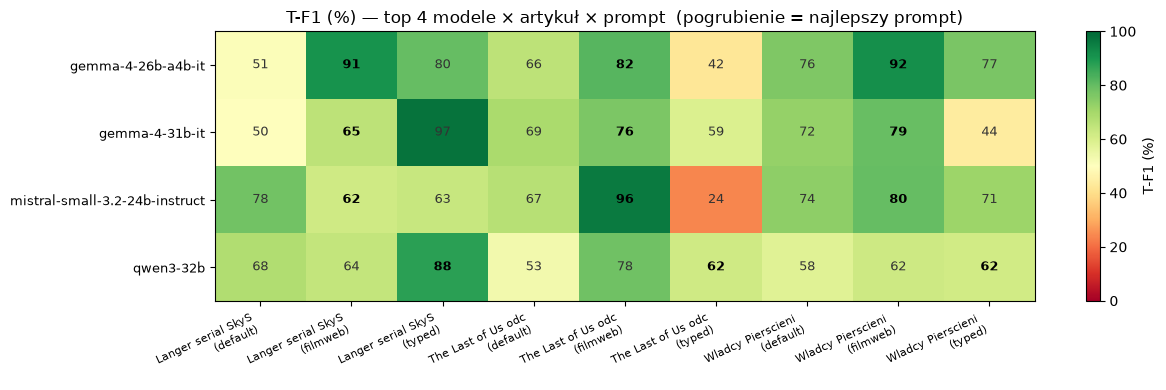

Model,Prompt,Prec.,Recall,F1,T-Prec.,T-Recall,T-F1
gemma-4-26b-a4b-it,filmweb,89.2%,70.7%,78.9%,95.0%,82.2%,88.1%
mistral-small-3.2-24b-instruct,filmweb,91.6%,69.4%,78.4%,84.5%,76.2%,79.4%
gemma-4-31b-it,filmweb,92.6%,67.9%,78.3%,96.3%,60.4%,73.7%
qwen3-32b,typed,89.5%,60.6%,72.2%,70.9%,70.6%,70.5%


In [36]:
# ── 6. Heatmapa T-F1 — tylko top 4 ───────────────────────────────────────────
df4b = df4.copy()
df4b["col"] = df4b["title_short"].str[:18] + "\n(" + df4b["prompt_label"] + ")"
pivot4 = (
    df4b.groupby(["model_short", "col"])["t_f1"]
    .mean().unstack("col")
    .reindex(TOP4) * 100
)
col_order4 = sorted(pivot4.columns,
    key=lambda c: (c.split("\n")[0], PROMPTS.index(c.split("(")[1].rstrip(")")) if c.split("(")[1].rstrip(")") in PROMPTS else 99))
pivot4 = pivot4[col_order4]

fig, ax = plt.subplots(figsize=(max(12, len(pivot4.columns)*1.4), 4))
im = ax.imshow(pivot4.values, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(pivot4.columns)))
ax.set_xticklabels(pivot4.columns, rotation=25, ha="right", fontsize=8)
ax.set_yticks(range(len(TOP4)))
ax.set_yticklabels(TOP4, fontsize=9)
for i in range(pivot4.shape[0]):
    for j in range(pivot4.shape[1]):
        val = pivot4.values[i, j]
        if not np.isnan(val):
            # pogrub najlepszy prompt dla danego modelu
            model = TOP4[i]
            prompt_in_col = pivot4.columns[j].split("(")[1].rstrip(")")
            bold = (TOP4_BEST_PROMPT[model] == prompt_in_col)
            ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=9,
                    fontweight="bold" if bold else "normal",
                    color="black" if bold else "#333")
fig.colorbar(im, label="T-F1 (%)")
ax.set_title("T-F1 (%) — top 4 modele × artykuł × prompt  (pogrubienie = najlepszy prompt)")
fig.tight_layout()
plt.show()

# ── 7. Finalna tabela rankingowa top 4 z najlepszym promptem ─────────────────
display(HTML("<h4>Finalna tabela — top 4 modele z najlepszym promptem</h4>"))
rows = []
for m in TOP4:
    best_p = TOP4_BEST_PROMPT[m]
    row = avg4[(avg4["model_short"]==m) & (avg4["prompt_label"]==best_p)].iloc[0]
    rows.append(row)
final_df = pd.DataFrame(rows).reset_index(drop=True)
display(
    final_df.sort_values("t_f1", ascending=False)
    .rename(columns={"model_short": "Model", "prompt_label": "Prompt",
                     "precision": "Prec.", "recall": "Recall", "f1": "F1",
                     "t_precision": "T-Prec.", "t_recall": "T-Recall", "t_f1": "T-F1"})
    .style
    .apply(color_prompt, axis=1)
    .background_gradient(subset=["Prec.","Recall","F1","T-Prec.","T-Recall","T-F1"],
                          cmap="RdYlGn", vmin=0, vmax=1)
    .format({c: "{:.1%}" for c in ["Prec.","Recall","F1","T-Prec.","T-Recall","T-F1"]})
    .set_table_styles([{"selector": "th", "props": [("white-space", "nowrap")]}])
    .hide(axis="index")
)

## Heatmapy: Precision, Recall, T-Precision, T-Recall — tylko top 4 modele × artykuł × prompt

In [ ]:
metrics4 = ["precision", "recall", "t_precision", "t_recall"]
mlabels4 = ["Precision", "Recall", "T-Precision", "T-Recall"]

df4b = df4.copy()
df4b["col"] = df4b["title_short"].str[:18] + "
(" + df4b["prompt_label"] + ")"
col_order4 = sorted(
    df4b["col"].unique(),
    key=lambda c: (c.split("
")[0], PROMPTS.index(c.split("(")[1].rstrip(")")) if c.split("(")[1].rstrip(")") in PROMPTS else 99)
)

fig, axes = plt.subplots(2, 2, figsize=(max(12, len(col_order4) * 1.4), 9))
axes = axes.flatten()

for ax, metric, mlabel in zip(axes, metrics4, mlabels4):
    pivot4m = (
        df4b.groupby(["model_short", "col"])[metric]
        .mean().unstack("col")
        .reindex(TOP4)[col_order4] * 100
    )
    im = ax.imshow(pivot4m.values, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")
    ax.set_xticks(range(len(pivot4m.columns)))
    ax.set_xticklabels(pivot4m.columns, rotation=25, ha="right", fontsize=7)
    ax.set_yticks(range(len(TOP4)))
    ax.set_yticklabels(TOP4, fontsize=8)
    for i in range(pivot4m.shape[0]):
        for j in range(pivot4m.shape[1]):
            val = pivot4m.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=7)
    fig.colorbar(im, ax=ax, label=f"{mlabel} (%)", fraction=0.046, pad=0.04)
    ax.set_title(f"{mlabel} (%)", fontsize=11, fontweight="bold")

fig.suptitle("Precision, Recall, T-Precision, T-Recall — top 4 modele × artykuł × prompt", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()


### Wnioski — 4 wybrane modele

**gemma-4-26b-a4b-it** (filmweb → T-F1 88.1%, +24 pp vs default)  
Bezwzględny lider całego eksperymentu. Prompt filmweb przynosi dramatyczną poprawę T-Recall (51.6% → 82.2%) przy jednoczesnym wzroście T-Precision (89.7% → 95.0%) — jedyny model gdzie zmiana promptu poprawia obie T-metryki jednocześnie. Wynik 88.1% T-F1 jest najwyższy w całym zbiorze badań.

**mistral-small-3.2-24b-instruct** (filmweb → T-F1 79.4%, +6.6 pp vs default)  
Najlepszy balans T-Precision i T-Recall z wszystkich czterech (84.5% / 76.2%). Poprawa dzięki filmweb jest umiarkowana bo model już na default był dobry (72.8%) — sufit jest niższy. Charakteryzuje się największą konsekwencją wyników między artykułami.

**gemma-4-31b-it** (filmweb → T-F1 73.7%, +9.9 pp vs default)  
Osiąga najwyższą T-Precision spośród czwórki z filmweb (96.3%) — relacje które ekstraktuje są niemal bezbłędne semantycznie. Słabszy punkt to T-Recall (60.4%), czyli model nadal pomija sporą część grafu referencyjnego. Paradoks: gemma-4-26b mimo mniejszej liczby parametrów wyprzedza 31b w T-F1 dzięki znacznie wyższemu T-Recall (82.2 vs 60.4).

**qwen3-32b** (typed → T-F1 70.5%, +10.7 pp vs default)  
Jedyny z czwórki gdzie najlepszym promptem jest `typed`, nie `filmweb`. Prompt typed daje mu zbalansowane T-Precision/T-Recall (70.9% / 70.6%) podczas gdy filmweb nie przynosi mu porównywalnej poprawy (68.2%). Sugeruje to że model lepiej reaguje na ustrukturyzowane wskazówki typowania relacji niż na kontekst dziedzinowy filmweb.

**Podsumowanie**  
Trzy z czterech modeli mają jednoznacznie najlepszy prompt `filmweb_pl`. Prompt `typed_pl` jest optymalny tylko dla qwen3-32b, dla pozostałych niszczy T-Precision. Dalsze badania (więcej artykułów, ewentualny fine-tuning promptu) powinny być prowadzone z `filmweb_pl` dla gemma i mistral oraz z `typed_pl` dla qwen3-32b.